In [10]:
import numpy as np
import seaborn as sns
import random
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
def calculate_sse(predicted, true, mask):
    predicted = predicted.astype(float)
    true = true.astype(float)
    error = (predicted - true) ** 2
    #print("Error matrix:\n", error)
    masked_error = error * mask
    #print("Masked error matrix:\n", masked_error)
    sse = np.sum(masked_error)
    return sse

<h4>Test primeri i vizualizacija razlike<h4>

In [12]:
# originalna RCBD tabela (npr. 3 tretmana x 3 bloka)
true_matrix = np.array([
    [10, 12, 14],
    [13, 15, 17],
    [11, 13, 16]
])

# maska:
#    true_matrix[0,1] = 12 i true_matrix[2,2] = 16
mask = np.zeros_like(true_matrix, dtype=float)

mask[0,1] = 1
mask[2,2] = 1

# predlozene vrednosti koje bi GA dao kao rešenja
predicted_matrix = true_matrix.astype(float)
predicted_matrix[0,1] = 11.5 #npr 11.5 umesto 12
predicted_matrix[2,2] = 17.5 #npr 17.5 umesto 16

sse = calculate_sse(predicted_matrix, true_matrix, mask)
print(f"SSE:  {sse:.4f}")

SSE:  2.5000


In [13]:
df_true = pd.DataFrame(true_matrix)
df_pred = pd.DataFrame(predicted_matrix)
df_mask = pd.DataFrame(mask)

error_matrix = (df_pred - df_true)
masked_error_matrix = error_matrix * df_mask

print("Razlika (samo na pozicijama sa greškom):")
display(masked_error_matrix)

Razlika (samo na pozicijama sa greškom):


,0,1,2
0,0.0,-0.5,0.0
1,0.0,0.0,0.0
2,0.0,0.0,1.5


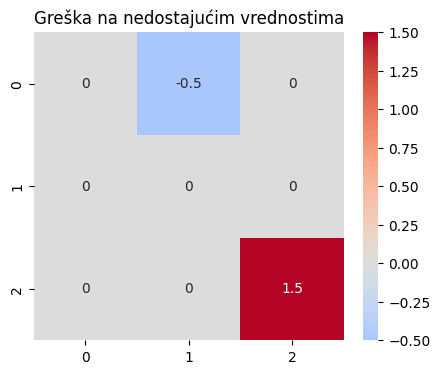

In [14]:
plt.figure(figsize=(5,4))
sns.heatmap(masked_error_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Greška na nedostajućim vrednostima")
plt.show()

In [15]:
#nasumicno uklanjanje jedne vrednosti iz rcbd tabele
def hide_random_value(table: pd.DataFrame):
    
    table_hidden = table.copy() #kopija tabele sa jednom vrednošću zamenjenom sa np.nan

    rows, cols = table.shape
    i = random.randint(0, rows - 1)
    j = random.randint(0, cols - 1)
    #(i,j) je pozicija gde je vrednost uklonjena

    true_value = table_hidden.iat[i, j] #originalna vrednost na (i,j) poziciji
    table_hidden.iat[i, j] = np.nan 

    return table_hidden, (i, j), true_value

In [19]:
#proba funkcije za uklanjanje jedne vrednosti
df = pd.DataFrame(np.random.uniform(10.0, 30.0, size=(5, 5)))
df = df.round(2)
print("Originalna tabela:")
print(df)

df_hidden, pos, original_val = hide_random_value(df)

print("\nTabela sa skrivenom vrednošću:")
print(df_hidden)

print(f"\nUklonjena vrednost: {original_val} na poziciji {pos}")

Originalna tabela:
       0      1      2      3      4
0  23.61  22.24  14.29  25.69  25.45
1  10.37  22.26  20.65  24.91  11.29
2  11.17  10.02  28.34  24.53  25.99
3  17.27  21.32  24.92  20.18  15.01
4  17.79  27.02  10.29  27.24  16.94

Tabela sa skrivenom vrednošću:
       0      1      2      3      4
0  23.61  22.24  14.29  25.69  25.45
1  10.37  22.26  20.65  24.91    NaN
2  11.17  10.02  28.34  24.53  25.99
3  17.27  21.32  24.92  20.18  15.01
4  17.79  27.02  10.29  27.24  16.94

Uklonjena vrednost: 11.29 na poziciji (1, 4)
